# Runtime Batch Benchmark (qubit-TransmonCross-Hamiltonian_params)
## Hamiltonian to Quantum Metal to Hamiltonian

Inverse plus surrogate and surrogate-only inference timing.

This notebook benchmarks time per sample versus batch number on CPU and GPU. 

## Configuration

In [8]:
## the parameter file has the path names for this experiment
## start there if you want to change the setup

from parameters_surrogate_defined_loss import *

## Library

In [9]:
import os, gc, json, time, platform, math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow.keras.models import load_model

try:
    for gpu in tf.config.list_physical_devices('GPU'):
        tf.config.experimental.set_memory_growth(gpu, True)
except Exception as e:
    print('Could not set GPU memory growth:', repr(e))

In [10]:
## grab the best models
encoding = 'surrogate_defined_loss'
COMBINED_MODEL_PATH = Path(MODEL_DIR) / f'best_keras_model_{encoding}.keras'
SURROGATE_MODEL_PATH = Path(MODEL_DIR) / 'best_keras_model_model2_surrogate.keras'

RUNTIME_DIR = Path(RESULTS_DIR) / 'runtime'
RUNTIME_DIR.mkdir(parents=True, exist_ok=True)
Path(PLOTS_DIR).mkdir(parents=True, exist_ok=True)

print(f'Combined inverse + surrogate model: {COMBINED_MODEL_PATH}')
print(f'Surrogate-only model:              {SURROGATE_MODEL_PATH}')
print(f'Runtime results dir:               {RUNTIME_DIR}')
print(f'Plots dir:                         {PLOTS_DIR}')

for model_path in [COMBINED_MODEL_PATH, SURROGATE_MODEL_PATH]:
    if not model_path.exists():
        raise FileNotFoundError(f'Missing model file: {model_path}')

Combined inverse + surrogate model: /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/model/best_keras_model_surrogate_defined_loss.keras
Surrogate-only model:              /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/model/best_keras_model_model2_surrogate.keras
Runtime results dir:               /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/results/runtime
Plots dir:                         /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/plots


## Dataset

### Load

In [11]:
def _load_npy(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f'Missing data file: {path}. If this is a fresh clone, unzip the supplemental data into this experiment folder first.'
        )
    return np.load(path, allow_pickle=True).astype('float32')

## combined model input is scaled Hamiltonian from ml_22
X_inverse_test = _load_npy(Path(DATA_DIR) / 'npy' / 'x_test_one_hot_encoding_augmented.npy')

## surrogate model input is scaled Quantum Metal params from ml_12/ml_21
X_surrogate_test = _load_npy(Path(DATA_DIR) / 'npy' / 'y_test_linear_encoding_scaled.npy')

with open(str(Path(METADATA_DIR) / 'X_names'), 'r') as f:
    Hamiltonian_column_names = f.read().splitlines()
qiskit_param_names = np.load(str(Path(METADATA_DIR) / 'y_columns.npy'), allow_pickle=True).astype(str).tolist()

print(f'Combined model benchmark input: {X_inverse_test.shape}')
print(f'Surrogate-only benchmark input: {X_surrogate_test.shape}')
print(f'Hamiltonian columns: {Hamiltonian_column_names}')
print(f'Quantum Metal columns: {qiskit_param_names}')

Combined model benchmark input: (291, 2)
Surrogate-only benchmark input: (291, 3)
Hamiltonian columns: ['qubit_frequency_GHz', 'anharmonicity_MHz']
Quantum Metal columns: ['design_options.connection_pads.readout.claw_length', 'design_options.connection_pads.readout.ground_spacing', 'design_options.cross_length']


### Define conversion layer

In [12]:
## must define this class before loading the saved combined model
class ScalerConversionLayer(tf.keras.layers.Layer):
    def __init__(self, scale_a, scale_b, **kwargs):
        kwargs.setdefault('trainable', False)
        super().__init__(**kwargs)
        self._scale_a = tf.constant(scale_a, dtype=tf.float32)
        self._scale_b = tf.constant(scale_b, dtype=tf.float32)
        self._cfg = dict(
            scale_a=list(scale_a) if hasattr(scale_a, '__iter__') else scale_a,
            scale_b=list(scale_b) if hasattr(scale_b, '__iter__') else scale_b,
        )

    def call(self, inputs):
        a = tf.cast(self._scale_a, inputs.dtype)
        b = tf.cast(self._scale_b, inputs.dtype)
        return inputs * a + b

    def get_config(self):
        config = super().get_config()
        config.update(self._cfg)
        return config

## Benchmark Setup

In [13]:
## do this many x axis points
BATCH_NUMBERS = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048]
N_WARMUP = 20
N_REPEAT = 50
RUN_CPU_BENCHMARK = True
RUN_GPU_BENCHMARK = True

####################### Ansys time per sample for percent-speedup plots, Firas update this if needed ##########################
ANSYS_SECONDS_PER_SAMPLE = 2.0 * 60.0

QCHEFF_COLORS = {
    'CPU': '#127cc1',
    'GPU': '#76b900',
}
QCHEFF_MARKERS = {
    'CPU': 'v',
    'GPU': '^',
}

GPU_DEVICES = tf.config.list_physical_devices('GPU')
GPU_AVAILABLE = len(GPU_DEVICES) > 0
print('CPU benchmark:', RUN_CPU_BENCHMARK)
print('GPU benchmark:', RUN_GPU_BENCHMARK, '| visible GPUs:', GPU_DEVICES)

CPU benchmark: True
GPU benchmark: True | visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [14]:
def make_batch(X, batch_number):
    ## tile the test set when a requested batch is larger than the held-out set
    X = np.asarray(X, dtype=np.float32)
    if len(X) >= batch_number:
        return X[:batch_number]
    reps = int(np.ceil(batch_number / len(X)))
    return np.tile(X, (reps, 1))[:batch_number]


def sync_tensorflow_outputs(outputs):
    ## force GPU work to finish before stopping the timer
    if isinstance(outputs, (list, tuple)):
        for output in outputs:
            sync_tensorflow_outputs(output)
    elif isinstance(outputs, dict):
        for output in outputs.values():
            sync_tensorflow_outputs(output)
    elif tf.is_tensor(outputs):
        _ = outputs.numpy()
    else:
        _ = np.asarray(outputs)


def call_model_once(model, x_tensor):
    outputs = model(x_tensor, training=False)
    sync_tensorflow_outputs(outputs)


def benchmark_model_path(model_path, X, benchmark_name, device_label, device_name, custom_objects=None):
    rows = []
    custom_objects = custom_objects or {}

    if device_label == 'GPU' and not GPU_AVAILABLE:
        print(f'Skipping {benchmark_name} on GPU because no TensorFlow GPU is visible.')
        return rows

    print(f'Loading {benchmark_name} on {device_label}: {model_path}')
    tf.keras.backend.clear_session()
    gc.collect()

    try:
        with tf.device(device_name):
            model = load_model(model_path, compile=False, custom_objects=custom_objects)
    except Exception as e:
        rows.append({
            'benchmark': benchmark_name,
            'device': device_label,
            'batch_number': np.nan,
            'repeat': np.nan,
            'status': 'load_error',
            'error': repr(e),
        })
        print(f'Could not load {benchmark_name} on {device_label}: {repr(e)}')
        return rows

    for batch_number in BATCH_NUMBERS:
        X_batch = make_batch(X, batch_number)
        try:
            with tf.device(device_name):
                x_tensor = tf.convert_to_tensor(X_batch, dtype=tf.float32)
                actual_tensor_device = x_tensor.device

                ## warmup to trigger tracing and kernel initialization
                for _ in range(N_WARMUP):
                    call_model_once(model, x_tensor)

                for repeat in range(N_REPEAT):
                    t0 = time.perf_counter()
                    call_model_once(model, x_tensor)
                    total_seconds = time.perf_counter() - t0

                    rows.append({
                        'benchmark': benchmark_name,
                        'device': device_label,
                        'device_name': device_name,
                        'actual_tensor_device': actual_tensor_device,
                        'batch_number': int(batch_number),
                        'repeat': int(repeat),
                        'total_seconds': float(total_seconds),
                        'time_per_sample_seconds': float(total_seconds / batch_number),
                        'status': 'ok',
                        'error': '',
                    })
        except Exception as e:
            rows.append({
                'benchmark': benchmark_name,
                'device': device_label,
                'device_name': device_name,
                'batch_number': int(batch_number),
                'repeat': np.nan,
                'status': 'benchmark_error',
                'error': repr(e),
            })
            print(f'Benchmark error for {benchmark_name} on {device_label}, batch {batch_number}: {repr(e)}')

    del model
    tf.keras.backend.clear_session()
    gc.collect()
    return rows

## Run Benchmarks

In [15]:
all_timing_rows = []

if RUN_CPU_BENCHMARK:
    all_timing_rows.extend(benchmark_model_path(
        COMBINED_MODEL_PATH,
        X_inverse_test,
        benchmark_name='inverse+surrogate',
        device_label='CPU',
        device_name='/CPU:0',
        custom_objects={'ScalerConversionLayer': ScalerConversionLayer},
    ))
    all_timing_rows.extend(benchmark_model_path(
        SURROGATE_MODEL_PATH,
        X_surrogate_test,
        benchmark_name='surrogate-only',
        device_label='CPU',
        device_name='/CPU:0',
    ))

if RUN_GPU_BENCHMARK:
    all_timing_rows.extend(benchmark_model_path(
        COMBINED_MODEL_PATH,
        X_inverse_test,
        benchmark_name='inverse+surrogate',
        device_label='GPU',
        device_name='/GPU:0',
        custom_objects={'ScalerConversionLayer': ScalerConversionLayer},
    ))
    all_timing_rows.extend(benchmark_model_path(
        SURROGATE_MODEL_PATH,
        X_surrogate_test,
        benchmark_name='surrogate-only',
        device_label='GPU',
        device_name='/GPU:0',
    ))

timing_raw_df = pd.DataFrame(all_timing_rows)
timing_raw_df.head()

Loading inverse+surrogate on CPU: /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/model/best_keras_model_surrogate_defined_loss.keras


I0000 00:00:1778018922.483799  627175 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1036 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe MIG 4g.40gb, pci bus id: 0000:06:00.0, compute capability: 8.0


Loading surrogate-only on CPU: /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/model/best_keras_model_model2_surrogate.keras
Loading inverse+surrogate on GPU: /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/model/best_keras_model_surrogate_defined_loss.keras
Loading surrogate-only on GPU: /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/model/best_keras_model_model2_surrogate.keras


,benchmark,device,device_name,actual_tensor_device,batch_number,repeat,total_seconds,time_per_sample_seconds,status,error
0,inverse+surrogate,CPU,/CPU:0,/job:localhost/replica:0/task:0/device:CPU:0,1,0,0.004905,0.004905,ok,
1,inverse+surrogate,CPU,/CPU:0,/job:localhost/replica:0/task:0/device:CPU:0,1,1,0.004894,0.004894,ok,
2,inverse+surrogate,CPU,/CPU:0,/job:localhost/replica:0/task:0/device:CPU:0,1,2,0.004778,0.004778,ok,
3,inverse+surrogate,CPU,/CPU:0,/job:localhost/replica:0/task:0/device:CPU:0,1,3,0.004916,0.004916,ok,
4,inverse+surrogate,CPU,/CPU:0,/job:localhost/replica:0/task:0/device:CPU:0,1,4,0.004849,0.004849,ok,


### Save

In [16]:
raw_path = RUNTIME_DIR / 'ml_30_runtime_batch_benchmark_raw.csv'
summary_path = RUNTIME_DIR / 'ml_30_runtime_batch_benchmark_summary.csv'
metadata_path = RUNTIME_DIR / 'ml_30_runtime_batch_benchmark_metadata.json'

if timing_raw_df.empty:
    raise RuntimeError('No timing rows were produced. Check benchmark settings and visible devices.')

timing_raw_df.to_csv(raw_path, index=False)

ok_df = timing_raw_df[timing_raw_df['status'] == 'ok'].copy()
if ok_df.empty:
    raise RuntimeError('No successful timing rows were produced. Check timing_raw_df for errors.')

summary_df = (
    ok_df
    .groupby(['benchmark', 'device', 'batch_number'], as_index=False)
    .agg(
        mean_total_seconds=('total_seconds', 'mean'),
        std_total_seconds=('total_seconds', 'std'),
        mean_time_per_sample_seconds=('time_per_sample_seconds', 'mean'),
        std_time_per_sample_seconds=('time_per_sample_seconds', 'std'),
        repeats=('time_per_sample_seconds', 'count'),
    )
)
summary_df['mean_time_per_sample_ms'] = summary_df['mean_time_per_sample_seconds'] * 1000.0
summary_df['std_time_per_sample_ms'] = summary_df['std_time_per_sample_seconds'] * 1000.0
summary_df.to_csv(summary_path, index=False)

metadata = {
    'created_by': 'ml_30_runtime_batch_benchmark.ipynb',
    'system': f'{platform.system()} {platform.release()}',
    'machine': platform.machine(),
    'processor': platform.processor(),
    'python': platform.python_version(),
    'tensorflow': tf.__version__,
    'gpu_available': GPU_AVAILABLE,
    'gpu_devices': [str(g) for g in GPU_DEVICES],
    'batch_numbers': BATCH_NUMBERS,
    'n_warmup': N_WARMUP,
    'n_repeat': N_REPEAT,
    'combined_model_path': str(COMBINED_MODEL_PATH),
    'surrogate_model_path': str(SURROGATE_MODEL_PATH),
    'ansys_seconds_per_sample': ANSYS_SECONDS_PER_SAMPLE,
}
with metadata_path.open('w') as f:
    json.dump(metadata, f, indent=2)

print(f'Saved raw timing data -> {raw_path}')
print(f'Saved timing summary -> {summary_path}')
print(f'Saved timing metadata -> {metadata_path}')
summary_df

Saved raw timing data -> /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/results/runtime/ml_30_runtime_batch_benchmark_raw.csv
Saved timing summary -> /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/results/runtime/ml_30_runtime_batch_benchmark_summary.csv
Saved timing metadata -> /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/results/runtime/ml_30_runtime_batch_benchmark_metadata.json


,benchmark,device,batch_number,mean_total_seconds,std_total_seconds,mean_time_per_sample_seconds,std_time_per_sample_seconds,repeats,mean_time_per_sample_ms,std_time_per_sample_ms
0,inverse+surrogate,CPU,1,0.004758,0.000214,0.004758,2.138072e-04,50,4.758487,0.213807
1,inverse+surrogate,CPU,2,0.004562,0.000087,0.002281,4.339255e-05,50,2.281237,0.043393
2,inverse+surrogate,CPU,4,0.004753,0.000210,0.001188,5.244977e-05,50,1.188150,0.052450
3,inverse+surrogate,CPU,8,0.004783,0.000139,0.000598,1.741384e-05,50,0.597896,0.017414
4,inverse+surrogate,CPU,16,0.004643,0.000213,0.000290,1.329323e-05,50,0.290180,0.013293
5,inverse+surrogate,CPU,32,0.004725,0.000221,0.000148,6.913915e-06,50,0.147672,0.006914
6,inverse+surrogate,CPU,64,0.004778,0.000582,0.000075,9.101111e-06,50,0.074651,0.009101
7,inverse+surrogate,CPU,128,0.004714,0.000132,0.000037,1.033879e-06,50,0.036826,0.001034
8,inverse+surrogate,CPU,256,0.006683,0.000665,0.000026,2.598926e-06,50,0.026104,0.002599
9,inverse+surrogate,CPU,512,0.007017,0.000852,0.000014,1.663966e-06,50,0.013705,0.001664


In [17]:
## save split CSV files too, since these are the two datasets plotted below
for benchmark_name in ['inverse+surrogate', 'surrogate-only']:
    safe_name = benchmark_name.replace('+', '_plus_').replace('-', '_')
    out_path = RUNTIME_DIR / f'ml_30_{safe_name}_batch_timing_summary.csv'
    summary_df[summary_df['benchmark'] == benchmark_name].to_csv(out_path, index=False)
    print(f'Saved {benchmark_name} summary -> {out_path}')

Saved inverse+surrogate summary -> /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/results/runtime/ml_30_inverse_plus_surrogate_batch_timing_summary.csv
Saved surrogate-only summary -> /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/results/runtime/ml_30_surrogate_only_batch_timing_summary.csv


## Plot Helpers

In [ ]:
def save_figure(fig, stem):
    pdf_path = Path(PLOTS_DIR) / f'{stem}.pdf'
    png_path = Path(PLOTS_DIR) / f'{stem}.png'
    fig.savefig(pdf_path, bbox_inches='tight')
    fig.savefig(png_path, dpi=300, bbox_inches='tight')
    print(f'Saved plot -> {pdf_path}')
    print(f'Saved plot -> {png_path}')


def plot_figure8_histogram(plot_df, title, stem):
    batches = sorted(plot_df['batch_number'].dropna().unique())
    order = [d for d in ['CPU', 'GPU'] if d in set(plot_df['device'])]
    x = np.arange(len(batches))
    width = 0.8 / max(len(order), 1)

    with (
        sns.axes_style('ticks'),
        sns.plotting_context('notebook'),
        matplotlib.rc_context({'mathtext.fontset': 'cm'}),
    ):
        fig, ax = plt.subplots(figsize=(7, 4), layout='constrained')
        for i, device in enumerate(order):
            sub = (
                plot_df[plot_df['device'] == device]
                .set_index('batch_number')
                .reindex(batches)
            )
            offset = (i - (len(order) - 1) / 2.0) * width
            ax.bar(
                x + offset,
                sub['mean_time_per_sample_seconds'],
                width=width,
                color=QCHEFF_COLORS[device],
                alpha=0.85,
                edgecolor='black',
                linewidth=0.6,
                label=device,
            )
        ax.set_yscale('log')
        ax.set_xlabel('Batch Number')
        ax.set_ylabel('Time per sample (s)')
        ax.set_title(title)
        ax.set_xticks(x)
        ax.set_xticklabels([str(b) for b in batches], rotation=45, ha='right')
        ax.grid(axis='y')
        ax.legend(frameon=False)
    save_figure(fig, stem)
    return fig, ax


def make_ansys_speedup_df(plot_df):
    speedup_df = plot_df.copy()
    speedup_df['ansys_seconds_per_sample'] = ANSYS_SECONDS_PER_SAMPLE
    speedup_df['speedup_ratio_from_ansys_time_per_sample'] = (
        ANSYS_SECONDS_PER_SAMPLE / speedup_df['mean_time_per_sample_seconds']
    )
    speedup_df['percent_speedup_from_ansys_time_per_sample'] = (
        speedup_df['speedup_ratio_from_ansys_time_per_sample'] - 1.0
    ) * 100.0
    return speedup_df


def plot_figure8_speedup_histogram(plot_df, title, stem):
    speedup_df = make_ansys_speedup_df(plot_df)
    speedup_col = 'percent_speedup_from_ansys_time_per_sample'
    batches = sorted(speedup_df['batch_number'].dropna().unique())
    order = [d for d in ['CPU', 'GPU'] if d in set(speedup_df['device'])]
    x = np.arange(len(batches))
    width = 0.8 / max(len(order), 1)

    with (
        sns.axes_style('ticks'),
        sns.plotting_context('notebook'),
        matplotlib.rc_context({'mathtext.fontset': 'cm'}),
    ):
        fig, ax = plt.subplots(figsize=(7, 4), layout='constrained')
        for i, device in enumerate(order):
            sub = (
                speedup_df[speedup_df['device'] == device]
                .set_index('batch_number')
                .reindex(batches)
            )
            offset = (i - (len(order) - 1) / 2.0) * width
            ax.bar(
                x + offset,
                sub[speedup_col],
                width=width,
                color=QCHEFF_COLORS[device],
                alpha=0.85,
                edgecolor='black',
                linewidth=0.6,
                label=device,
            )
        if speedup_df[speedup_col].dropna().min() > 0:
            ax.set_yscale('log')
        ax.set_xlabel('Batch Number')
        ax.set_ylabel('Percent speedup from Ansys time per sample (%)')
        ax.set_title(title)
        ax.set_xticks(x)
        ax.set_xticklabels([str(b) for b in batches], rotation=45, ha='right')
        ax.grid(axis='y')
        ax.legend(frameon=False)
    save_figure(fig, stem)
    return fig, ax, speedup_df

## Inverse Plus Surrogate Runtime

In [19]:
inverse_surrogate_df = summary_df[summary_df['benchmark'] == 'inverse+surrogate'].copy()
inverse_surrogate_df

,benchmark,device,batch_number,mean_total_seconds,std_total_seconds,mean_time_per_sample_seconds,std_time_per_sample_seconds,repeats,mean_time_per_sample_ms,std_time_per_sample_ms
0,inverse+surrogate,CPU,1,0.004758,0.000214,0.004758,2.138072e-04,50,4.758487,0.213807
1,inverse+surrogate,CPU,2,0.004562,0.000087,0.002281,4.339255e-05,50,2.281237,0.043393
2,inverse+surrogate,CPU,4,0.004753,0.000210,0.001188,5.244977e-05,50,1.188150,0.052450
3,inverse+surrogate,CPU,8,0.004783,0.000139,0.000598,1.741384e-05,50,0.597896,0.017414
4,inverse+surrogate,CPU,16,0.004643,0.000213,0.000290,1.329323e-05,50,0.290180,0.013293
5,inverse+surrogate,CPU,32,0.004725,0.000221,0.000148,6.913915e-06,50,0.147672,0.006914
6,inverse+surrogate,CPU,64,0.004778,0.000582,0.000075,9.101111e-06,50,0.074651,0.009101
7,inverse+surrogate,CPU,128,0.004714,0.000132,0.000037,1.033879e-06,50,0.036826,0.001034
8,inverse+surrogate,CPU,256,0.006683,0.000665,0.000026,2.598926e-06,50,0.026104,0.002599
9,inverse+surrogate,CPU,512,0.007017,0.000852,0.000014,1.663966e-06,50,0.013705,0.001664


Saved plot -> /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/plots/ml_30_inverse_surrogate_runtime_histogram_vs_batch_number.pdf
Saved plot -> /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/plots/ml_30_inverse_surrogate_runtime_histogram_vs_batch_number.png


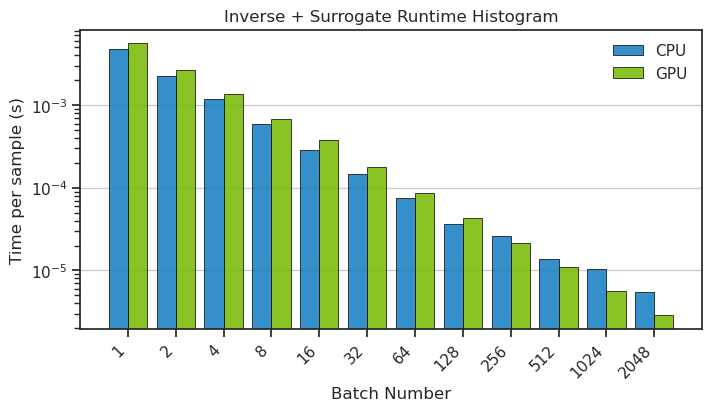

In [21]:
fig, ax = plot_figure8_histogram(
    inverse_surrogate_df,
    title='Inverse + Surrogate Runtime Histogram',
    stem='ml_30_inverse_surrogate_runtime_histogram_vs_batch_number',
)
plt.show()

## Surrogate-Only Runtime

In [22]:
surrogate_only_df = summary_df[summary_df['benchmark'] == 'surrogate-only'].copy()
surrogate_only_df

,benchmark,device,batch_number,mean_total_seconds,std_total_seconds,mean_time_per_sample_seconds,std_time_per_sample_seconds,repeats,mean_time_per_sample_ms,std_time_per_sample_ms
24,surrogate-only,CPU,1,0.002282,0.000321,0.002282,3.208314e-04,50,2.282324,0.320831
25,surrogate-only,CPU,2,0.002003,0.000069,0.001002,3.463402e-05,50,1.001717,0.034634
26,surrogate-only,CPU,4,0.002336,0.000240,0.000584,6.007232e-05,50,0.584070,0.060072
27,surrogate-only,CPU,8,0.001995,0.000071,0.000249,8.818131e-06,50,0.249321,0.008818
28,surrogate-only,CPU,16,0.002010,0.000052,0.000126,3.266938e-06,50,0.125603,0.003267
29,surrogate-only,CPU,32,0.002066,0.000077,0.000065,2.420301e-06,50,0.064576,0.002420
30,surrogate-only,CPU,64,0.002093,0.000131,0.000033,2.040129e-06,50,0.032704,0.002040
31,surrogate-only,CPU,128,0.002220,0.000137,0.000017,1.072152e-06,50,0.017341,0.001072
32,surrogate-only,CPU,256,0.004060,0.000725,0.000016,2.832783e-06,50,0.015859,0.002833
33,surrogate-only,CPU,512,0.003838,0.000154,0.000007,3.008370e-07,50,0.007496,0.000301


Saved plot -> /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/plots/ml_30_surrogate_only_runtime_histogram_vs_batch_number.pdf
Saved plot -> /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/plots/ml_30_surrogate_only_runtime_histogram_vs_batch_number.png


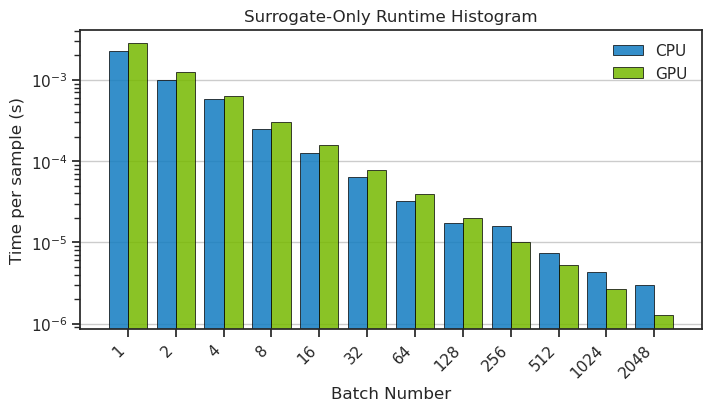

In [24]:
fig, ax = plot_figure8_histogram(
    surrogate_only_df,
    title='Surrogate-Only Runtime Histogram',
    stem='ml_30_surrogate_only_runtime_histogram_vs_batch_number',
)
plt.show()

## Surrogate-Only Speedup

In [ ]:
fig, ax, surrogate_only_speedup_df = plot_figure8_speedup_histogram(
    surrogate_only_df,
    title='Surrogate-Only Percent Speedup from Ansys Histogram',
    stem='ml_30_surrogate_only_percent_speedup_from_ansys_histogram_vs_batch_number',
)

surrogate_speedup_path = RUNTIME_DIR / 'ml_30_surrogate_only_percent_speedup_from_ansys.csv'
surrogate_only_speedup_df.to_csv(surrogate_speedup_path, index=False)
print(f'Saved surrogate speedup data -> {surrogate_speedup_path}')
plt.show()
surrogate_only_speedup_df

## Quick Comparison

In [26]:
## compact table with the fastest per-sample timing for each benchmark/device
fastest = (
    summary_df
    .sort_values('mean_time_per_sample_seconds')
    .groupby(['benchmark', 'device'], as_index=False)
    .first()[['benchmark', 'device', 'batch_number', 'mean_time_per_sample_seconds', 'mean_time_per_sample_ms']]
)
fastest

,benchmark,device,batch_number,mean_time_per_sample_seconds,mean_time_per_sample_ms
0,inverse+surrogate,CPU,2048,0.000006,0.005524
1,inverse+surrogate,GPU,2048,0.000003,0.002856
2,surrogate-only,CPU,2048,0.000003,0.003022
3,surrogate-only,GPU,2048,0.000001,0.001259
